In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Admission_Predict_2022_2026_skewed.csv")
df.columns = df.columns.str.strip()
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,Year
0,1,326,115,4,4.5,4.5,8.713564,1,0.92,2022
1,2,296,98,4,4.0,4.5,7.174594,1,0.76,2022
2,3,292,95,3,3.0,3.5,6.798360,1,0.72,2022
3,4,295,101,3,3.5,2.5,7.016065,1,0.80,2022
4,5,291,95,2,2.0,3.0,6.832066,0,0.65,2022


In [3]:
# Select the numerical columns for skewness 

num_cols = [
    "GRE Score",
    "TOEFL Score",
    "University Rating",
    "SOP",
    "LOR",
    "CGPA",
    "Research",
    "Chance of Admit"
]

# Display selected columns
print("Numerical columns:")
print(num_cols)

Numerical columns:
['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']


In [4]:
# calculate skewness 

skewness = df[num_cols].skew()

print("Skewness Before Transformation:")
print(skewness)

Skewness Before Transformation:
GRE Score            2.022737
TOEFL Score          1.005994
University Rating    0.048623
SOP                 -0.257402
LOR                 -0.093620
CGPA                 2.006651
Research            -0.012018
Chance of Admit     -0.356161
dtype: float64


In [5]:
#check the with col is highly skw
skewed_cols = skewness[abs(skewness) > 1].index.tolist()

if len(skewed_cols) > 0:
    print("highly skewed columns:")
    print(skewed_cols)
else:
    print("no highly skewed columns found!")

highly skewed columns:
['GRE Score', 'TOEFL Score', 'CGPA']


In [6]:
# create a copy of the original dataset for after compairesion
df_original = df.copy()

print("Original dataset copied successfully.")

Original dataset copied successfully.


In [7]:
# create another copy for log transformation
df_log = df_original.copy()

# Apply log transformation ONLY to highly skewed columns
for col in skewed_cols:
    df_log[col] = np.log1p(df_log[col])

print("log transformation applied only to highly skewed columns.")
print(skewed_cols)

log transformation applied only to highly skewed columns.
['GRE Score', 'TOEFL Score', 'CGPA']


In [8]:
after = df_log[skewed_cols].skew()

print("skewness after log transformation:")
print(after)

skewness after log transformation:
GRE Score      1.948942
TOEFL Score    0.899592
CGPA           1.828263
dtype: float64


In [9]:
# compair the befor and after tranform

comparison = pd.DataFrame({
    "Before": skewness[skewed_cols],
    "After": after
})

print("Skewness Comparison - Only Changed Columns:")
print(comparison)

Skewness Comparison - Only Changed Columns:
               Before     After
GRE Score    2.022737  1.948942
TOEFL Score  1.005994  0.899592
CGPA         2.006651  1.828263


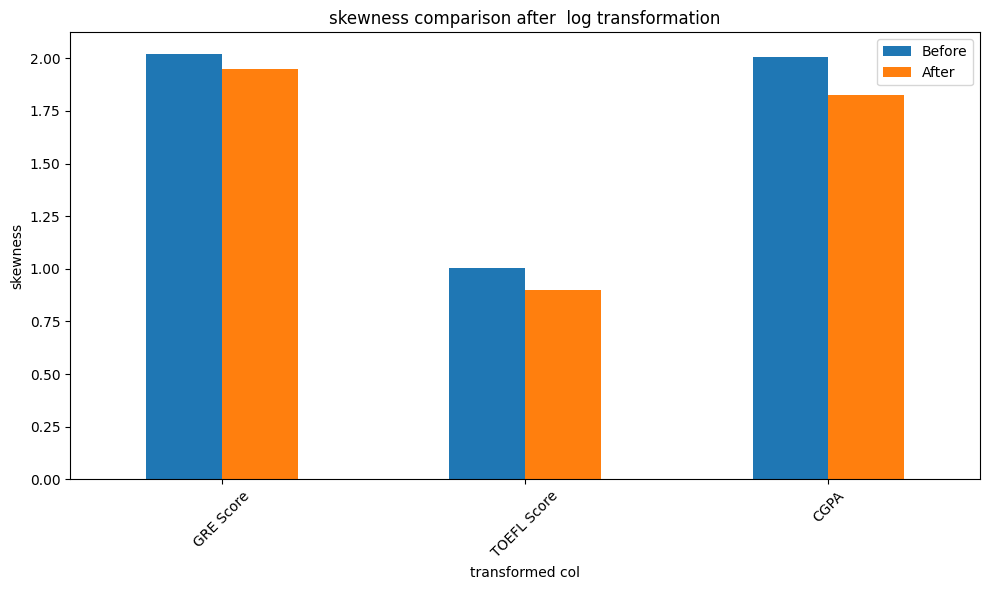

In [10]:
# Plot skewness comparison graph

comparison.plot(kind="bar", figsize=(10, 6))

plt.title("skewness comparison after  log transformation")
plt.xlabel("transformed col")
plt.ylabel("skewness")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# another techiques 
from sklearn.preprocessing import PowerTransformer
df_original = df.copy()

In [14]:
# calculate skewness before transformation
skew_before = df[num_cols].skew()
print("skewness bbefore transformation")
print(skew_before)
skewed_cols = skew_before[abs(skew_before) > 1].index
print("\nhighly skewed col:")
print(list(skewed_cols))

skewness bbefore transformation
GRE Score            2.022737
TOEFL Score          1.005994
University Rating    0.048623
SOP                 -0.257402
LOR                 -0.093620
CGPA                 2.006651
Research            -0.012018
Chance of Admit     -0.356161
dtype: float64

highly skewed col:
['GRE Score', 'TOEFL Score', 'CGPA']


In [15]:
# apply Yeo-Johnson Transformation
pt = PowerTransformer(method='yeo-johnson')
df[skewed_cols] = pt.fit_transform(df[skewed_cols])

In [19]:
# calculate skewness after transformation
skew_after = df[skewed_cols].skew()
print("\nskewness after Yeo-Johnson Transformation")
print(skew_after)

# comparison only for highly skewed columns
comparison = pd.DataFrame({
    'Before': skew_before[skewed_cols],
    'After': skew_after
})
print("\ncomparison of highly skewed columns")
print(comparison)


skewness after Yeo-Johnson Transformation
GRE Score      0.0
TOEFL Score    0.0
CGPA           0.0
dtype: float64

comparison of highly skewed columns
               Before  After
GRE Score    2.022737    0.0
TOEFL Score  1.005994    0.0
CGPA         2.006651    0.0


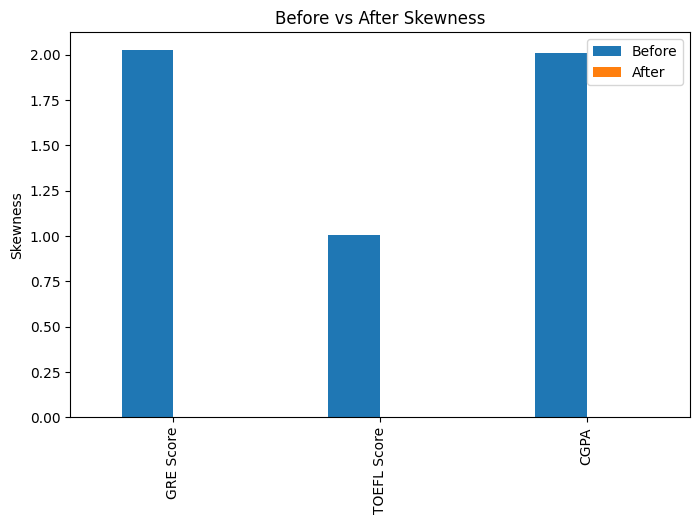

In [20]:
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    'Before': skew_before[skewed_cols],
    'After': skew_after
})

comparison.plot(kind='bar', figsize=(8,5))

plt.title("Before vs After Skewness")
plt.ylabel("Skewness")
plt.show()